Cargar el archivo AprobacionCurso.xlsx

In [ ]:
import pandas as pd

file_path = 'AprobacionCurso.xlsx'
df = pd.read_excel(file_path)

print("File loaded successfully. Here are the first 5 rows:")
print(df.head())
df.info()

File loaded successfully. Here are the first 5 rows:
   ID Año - Semestre      Felder  Examen_admisión  Nota_final Aprobo
0   1        2016-01   sensorial             4.67         3.1     si
1   2        2016-01      activo             4.17         2.1     no
2   3        2016-01      visual             4.50         3.1     si
3   4        2016-01      visual             3.83         1.6     no
4   5        2016-01  equilibrio             3.00         2.3     no
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183 entries, 0 to 182
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               183 non-null    int64  
 1   Año - Semestre   183 non-null    object 
 2   Felder           183 non-null    object 
 3   Examen_admisión  181 non-null    float64
 4   Nota_final       183 non-null    float64
 5   Aprobo           183 non-null    object 
dtypes: float64(2), int64(1), object(3)
memory usage: 8.7+ KB

Eliminar las variables ID, ano-semestre, Aprobo

In [ ]:
df = df.drop(columns=['ID', 'Año - Semestre', 'Nota_final'])

print("Columns removed successfully. Here's the updated DataFrame information:")
df.info()

Columns removed successfully. Here's the updated DataFrame information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183 entries, 0 to 182
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Felder           183 non-null    object 
 1   Examen_admisión  181 non-null    float64
 2   Aprobo           183 non-null    object 
dtypes: float64(1), object(2)
memory usage: 4.4+ KB


aplica one hot encoding a la variable Felder y elimina la variable original

In [ ]:
df = pd.get_dummies(df, columns=['Felder'], drop_first=True)

print("One-hot encoding applied to 'Felder' variable. Here's the updated DataFrame information:")
df.info()

One-hot encoding applied to 'Felder' variable. Here's the updated DataFrame information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183 entries, 0 to 182
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Examen_admisión    181 non-null    float64
 1   Aprobo             183 non-null    object 
 2   Felder_equilibrio  183 non-null    bool   
 3   Felder_intuitivo   183 non-null    bool   
 4   Felder_reflexivo   183 non-null    bool   
 5   Felder_secuencial  183 non-null    bool   
 6   Felder_sensorial   183 non-null    bool   
 7   Felder_verbal      183 non-null    bool   
 8   Felder_visual      183 non-null    bool   
dtypes: bool(7), float64(1), object(1)
memory usage: 4.2+ KB


normaliza la variable Examen_admisión con minmax scaler

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import joblib

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Reshape 'Examen_admisión' column to a 2D array for scaling and add it as a new column
df['Examen_admision_scaled'] = scaler.fit_transform(df[['Examen_admisión']])

# Remove the original 'Examen_admisión' column
df = df.drop(columns=['Examen_admisión'])

# Define the file path to save the scaler
scaler_file_path = 'min_max_scaler.joblib'

# Save the fitted MinMaxScaler object
joblib.dump(scaler, scaler_file_path)

print("DataFrame después de normalizar y eliminar 'Examen_admisión':")
print(df.head())
print(f"El MinMaxScaler ha sido guardado exitosamente en: {scaler_file_path}")

DataFrame después de normalizar y eliminar 'Examen_admisión':
  Aprobo  Felder_equilibrio  Felder_intuitivo  Felder_reflexivo  \
0     si              False             False             False   
1     no              False             False             False   
2     si              False             False             False   
3     no              False             False             False   
4     no               True             False             False   

   Felder_secuencial  Felder_sensorial  Felder_verbal  Felder_visual  \
0              False              True          False          False   
1              False             False          False          False   
2              False             False          False           True   
3              False             False          False           True   
4              False             False          False          False   

   Examen_admision_scaled  
0                   0.934  
1                   0.834  
2                 

Transforma true en 1 y false en 0 de toda las variables dummies y de la variable Aprobo no en 0 y si en 1

In [ ]:
for col in df.columns:
    if df[col].dtype == 'bool':
        df[col] = df[col].astype(int)

df['Aprobo'] = df['Aprobo'].map({'no': 0, 'si': 1})

print("DataFrame after transforming boolean and 'Aprobo' columns:")
print(df.head())
df.info()

DataFrame after transforming boolean and 'Aprobo' columns:
   Aprobo  Felder_equilibrio  Felder_intuitivo  Felder_reflexivo  \
0       1                  0                 0                 0   
1       0                  0                 0                 0   
2       1                  0                 0                 0   
3       0                  0                 0                 0   
4       0                  1                 0                 0   

   Felder_secuencial  Felder_sensorial  Felder_verbal  Felder_visual  \
0                  0                 1              0              0   
1                  0                 0              0              0   
2                  0                 0              0              1   
3                  0                 0              0              1   
4                  0                 0              0              0   

   Examen_admision_scaled  
0                   0.934  
1                   0.834  
2              

genera el modelo de regresion logistica multivariada y muestra los coeficientes calculados. genere las metricas de evaluacion

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# Handle missing values in 'Examen_admision_scaled' by filling with the mean
df['Examen_admision_scaled'] = df['Examen_admision_scaled'].fillna(df['Examen_admision_scaled'].mean())

# Define features (X) and target (y)
X = df.drop('Aprobo', axis=1)
y = df['Aprobo']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train the Logistic Regression model
model = LogisticRegression(solver='liblinear', random_state=42)
model.fit(X_train, y_train)

# Display coefficients
print("\n--- Model Coefficients ---")
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {model.intercept_[0]:.4f}")

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("\n--- Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


--- Model Coefficients ---
Felder_equilibrio: -0.0667
Felder_intuitivo: -0.5635
Felder_reflexivo: 0.0752
Felder_secuencial: -0.0345
Felder_sensorial: -0.2437
Felder_verbal: -0.4313
Felder_visual: -0.1118
Examen_admision_scaled: 1.4397
Intercept: -1.4048

--- Model Evaluation ---
Accuracy: 0.5818

Classification Report:
              precision    recall  f1-score   support

           0       0.57      1.00      0.72        30
           1       1.00      0.08      0.15        25

    accuracy                           0.58        55
   macro avg       0.78      0.54      0.44        55
weighted avg       0.76      0.58      0.46        55


Confusion Matrix:
[[30  0]
 [23  2]]


grafique el modelo de regresion logistica

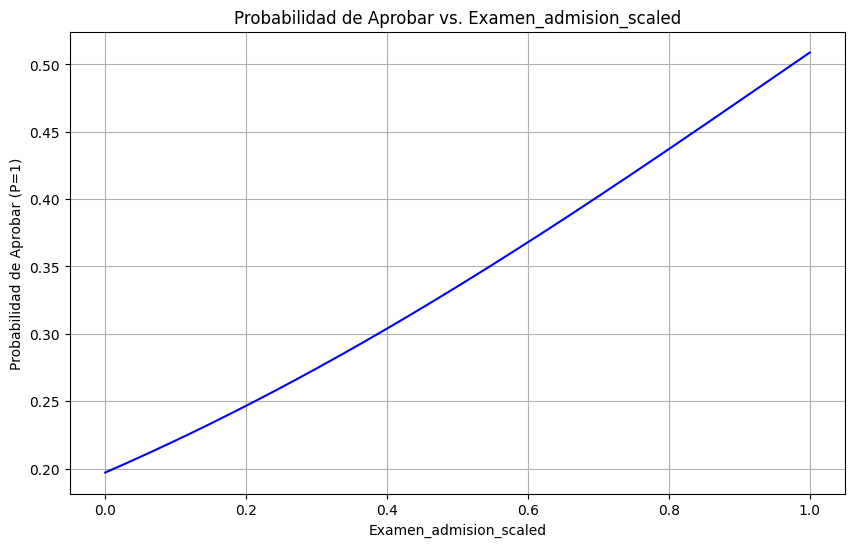

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Get the feature names from the training data
feature_names = X_train.columns

# Create a range of 'Examen_admision_scaled' values for plotting
examen_admision_range = np.linspace(X['Examen_admision_scaled'].min(), X['Examen_admision_scaled'].max(), 300)

# Create a DataFrame for prediction. Set other features (Felder types) to 0 for simplicity
# This assumes a baseline where no specific Felder type is prominent, allowing to observe
# the effect of Examen_admision_scaled.
plot_df = pd.DataFrame(0, index=range(len(examen_admision_range)), columns=feature_names)
plot_df['Examen_admision_scaled'] = examen_admision_range

# Predict probabilities
# model.predict_proba returns probabilities for both classes [P(class 0), P(class 1)]
# We are interested in P(Aprobo = 1)
probabilities = model.predict_proba(plot_df)[:, 1]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(examen_admision_range, probabilities, color='blue')
plt.xlabel('Examen_admision_scaled')
plt.ylabel('Probabilidad de Aprobar (P=1)')
plt.title('Probabilidad de Aprobar vs. Examen_admision_scaled')
plt.grid(True)
plt.show()


entrene 2 modelos de arbol de desicion, uno con division 70/30 para entrenamiento y prueba, y otro con cross validation, grafica los arboles y genera las metricas

--- Decision Tree Model 1: 70/30 Train-Test Split ---
Accuracy: 0.6545

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.90      0.74        30
           1       0.75      0.36      0.49        25

    accuracy                           0.65        55
   macro avg       0.69      0.63      0.61        55
weighted avg       0.68      0.65      0.62        55


Confusion Matrix:
[[27  3]
 [16  9]]


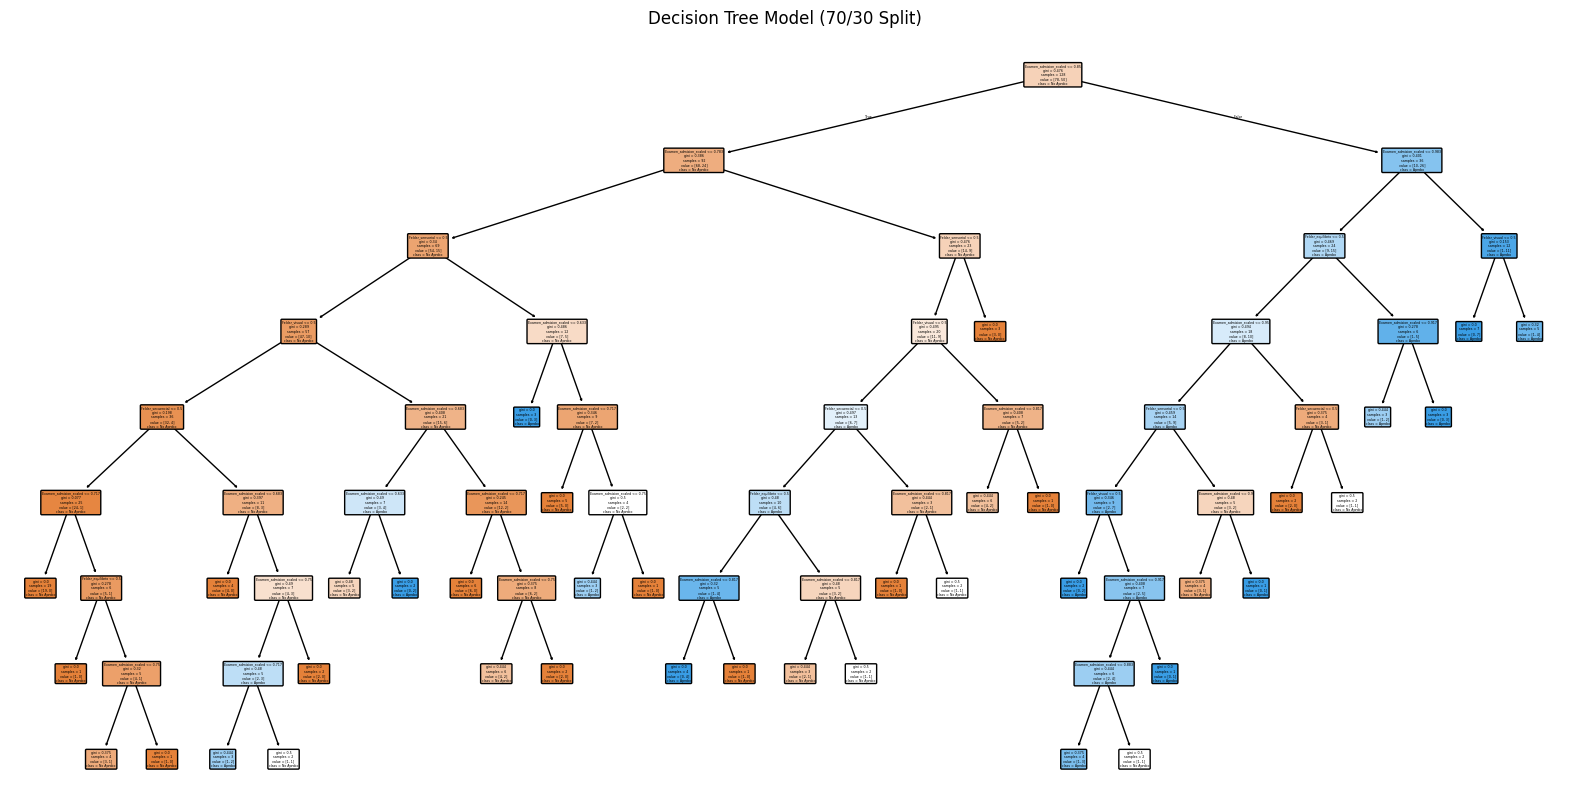


--- Decision Tree Model 2: Cross-Validation ---
Cross-Validation Accuracy Scores: [0.62162162 0.67567568 0.75675676 0.83333333 0.63888889]
Mean CV Accuracy: 0.7053
Standard Deviation of CV Accuracy: 0.0792


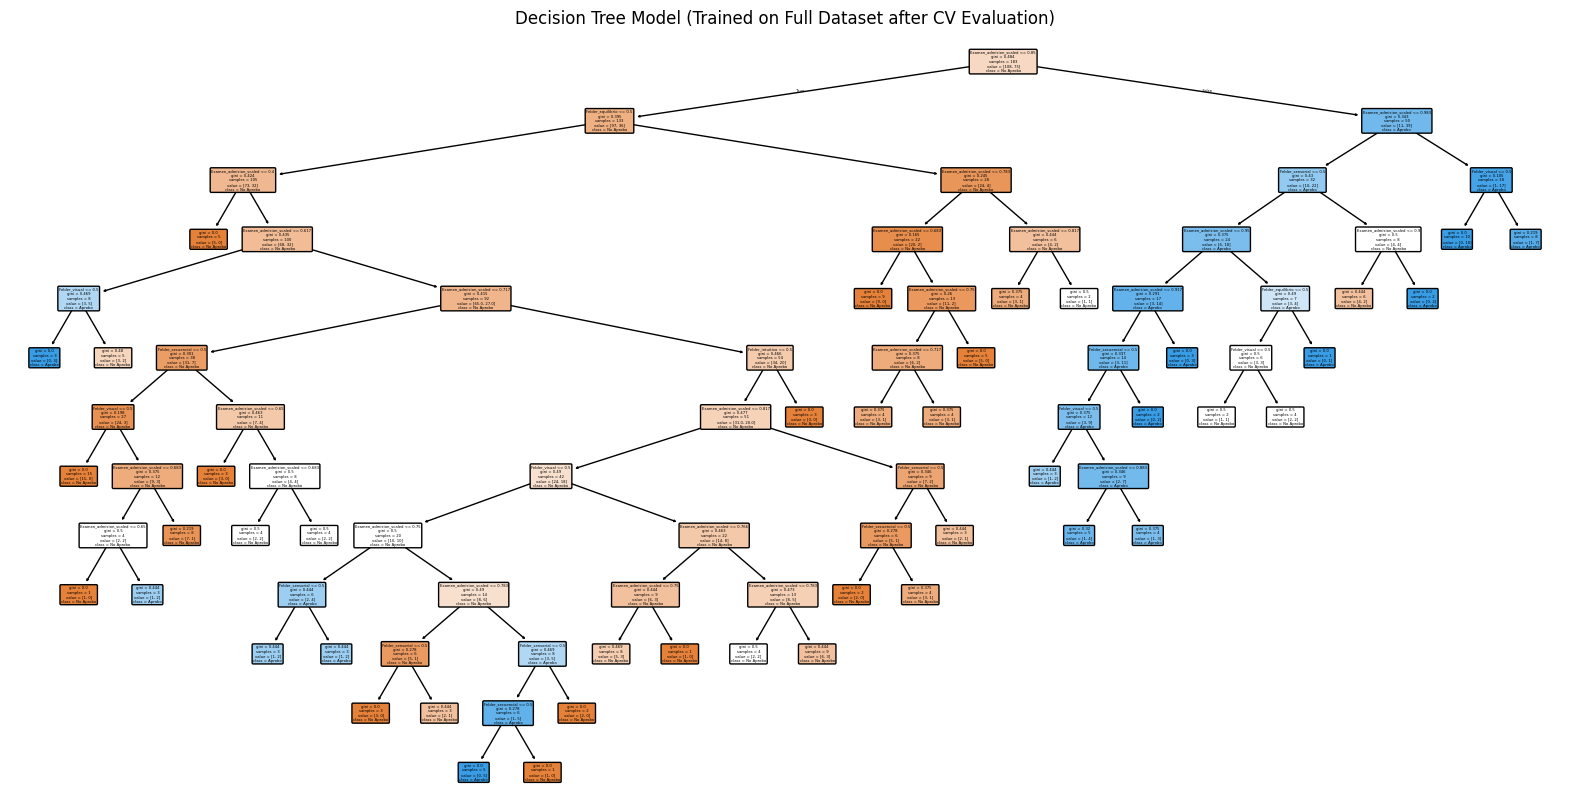

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

print("--- Decision Tree Model 1: 70/30 Train-Test Split ---")

# Split data for the first model (70/30)
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train Decision Tree Classifier
model_dt_split = DecisionTreeClassifier(random_state=42)
model_dt_split.fit(X_train_dt, y_train_dt)

# Make predictions
y_pred_dt_split = model_dt_split.predict(X_test_dt)

# Evaluate the model
print(f"Accuracy: {accuracy_score(y_test_dt, y_pred_dt_split):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_dt, y_pred_dt_split))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_dt, y_pred_dt_split))

# Plot the Decision Tree (Model 1)
plt.figure(figsize=(20, 10))
plot_tree(model_dt_split, feature_names=X.columns.tolist(), class_names=['No Aprobo', 'Aprobo'], filled=True, rounded=True)
plt.title('Decision Tree Model (70/30 Split)')
plt.show()

print("\n--- Decision Tree Model 2: Cross-Validation ---")

# Initialize Decision Tree Classifier for cross-validation
model_dt_cv = DecisionTreeClassifier(random_state=42)

# Perform 5-fold cross-validation
cv_scores = cross_val_score(model_dt_cv, X, y, cv=5)

print(f"Cross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f}")
print(f"Standard Deviation of CV Accuracy: {np.std(cv_scores):.4f}")

# For visualization, train a final Decision Tree on the entire dataset
# This tree represents the model found after evaluating with CV for understanding the structure.
model_dt_final_cv_plot = DecisionTreeClassifier(random_state=42)
model_dt_final_cv_plot.fit(X, y)

# Plot the Decision Tree (Model 2 - trained on full dataset for visualization)
plt.figure(figsize=(20, 10))
plot_tree(model_dt_final_cv_plot, feature_names=X.columns.tolist(), class_names=['No Aprobo', 'Aprobo'], filled=True, rounded=True)
plt.title('Decision Tree Model (Trained on Full Dataset after CV Evaluation)')
plt.show()


Entrena modelos KNN con cross validation para diferentes valores de K, calcula las metricas

--- KNN Models with Cross-Validation ---
K = 1: Mean CV Accuracy = 0.5407, Std Dev = 0.0630
K = 2: Mean CV Accuracy = 0.6664, Std Dev = 0.0548
K = 3: Mean CV Accuracy = 0.6284, Std Dev = 0.0946
K = 4: Mean CV Accuracy = 0.6938, Std Dev = 0.0369
K = 5: Mean CV Accuracy = 0.6827, Std Dev = 0.0394
K = 6: Mean CV Accuracy = 0.7102, Std Dev = 0.0591
K = 7: Mean CV Accuracy = 0.6614, Std Dev = 0.0346
K = 8: Mean CV Accuracy = 0.6776, Std Dev = 0.0265
K = 9: Mean CV Accuracy = 0.6667, Std Dev = 0.0315
K = 10: Mean CV Accuracy = 0.6938, Std Dev = 0.0535
K = 11: Mean CV Accuracy = 0.6827, Std Dev = 0.0522
K = 12: Mean CV Accuracy = 0.7047, Std Dev = 0.0485
K = 13: Mean CV Accuracy = 0.6937, Std Dev = 0.0384
K = 14: Mean CV Accuracy = 0.6992, Std Dev = 0.0401
K = 15: Mean CV Accuracy = 0.6938, Std Dev = 0.0445
K = 16: Mean CV Accuracy = 0.6992, Std Dev = 0.0401
K = 17: Mean CV Accuracy = 0.7047, Std Dev = 0.0514
K = 18: Mean CV Accuracy = 0.6830, Std Dev = 0.0330
K = 19: Mean CV Accuracy = 0.699

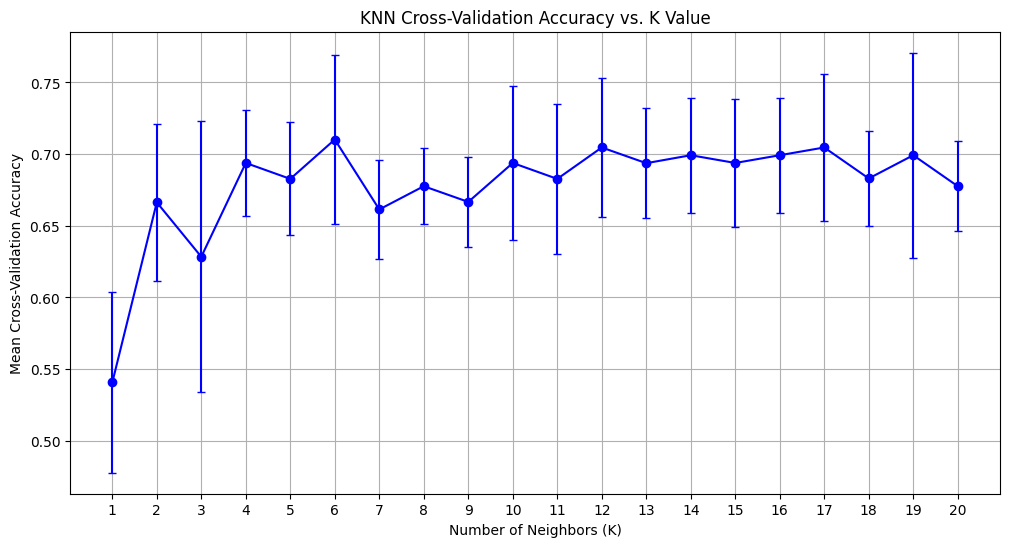


Best K found: 6 with a Mean CV Accuracy of 0.7102


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np

# Define a range of K values to test
k_values = list(range(1, 21)) # Test K from 1 to 20

# Store mean accuracy for each K
mean_accuracies = []
std_accuracies = []

print("--- KNN Models with Cross-Validation ---")

for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    # Perform 5-fold cross-validation
    cv_scores = cross_val_score(knn_model, X, y, cv=5, scoring='accuracy')

    mean_acc = np.mean(cv_scores)
    std_acc = np.std(cv_scores)

    mean_accuracies.append(mean_acc)
    std_accuracies.append(std_acc)

    print(f"K = {k}: Mean CV Accuracy = {mean_acc:.4f}, Std Dev = {std_acc:.4f}")

# Plotting the results
plt.figure(figsize=(12, 6))
plt.errorbar(k_values, mean_accuracies, yerr=std_accuracies, capsize=3, fmt='-o', color='blue')
plt.title('KNN Cross-Validation Accuracy vs. K Value')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()

# Find the best K based on mean accuracy
best_k_index = np.argmax(mean_accuracies)
best_k = k_values[best_k_index]
best_mean_accuracy = mean_accuracies[best_k_index]

print(f"\nBest K found: {best_k} with a Mean CV Accuracy of {best_mean_accuracy:.4f}")


entrena un modelo de soporte vectorial svm con cross valiation y genera las metricas

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
import numpy as np

print("--- SVM Model with Cross-Validation ---")

# Initialize the SVM classifier
# Using a linear kernel as a starting point, C=1.0 is the default regularization parameter
svm_model = SVC(kernel='linear', random_state=42)

# Perform 5-fold cross-validation
cv_scores_svm = cross_val_score(svm_model, X, y, cv=5, scoring='accuracy')

print(f"Cross-Validation Accuracy Scores for SVM: {cv_scores_svm}")
print(f"Mean CV Accuracy for SVM: {np.mean(cv_scores_svm):.4f}")
print(f"Standard Deviation of CV Accuracy for SVM: {np.std(cv_scores_svm):.4f}")


--- SVM Model with Cross-Validation ---
Cross-Validation Accuracy Scores for SVM: [0.72972973 0.64864865 0.7027027  0.66666667 0.63888889]
Mean CV Accuracy for SVM: 0.6773
Standard Deviation of CV Accuracy for SVM: 0.0341


entrene un modelo de red neuronal con cross validation y genere las metricas

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

print("--- Neural Network Model with Cross-Validation ---")

# Initialize the MLPClassifier (Neural Network)
# Using default parameters for simplicity. Hidden layer size and activation can be tuned.
mlp_model = MLPClassifier(hidden_layer_sizes=(100,100,), activation='relu', solver='adam', max_iter=200, random_state=42)

# Perform 5-fold cross-validation
cv_scores_mlp = cross_val_score(mlp_model, X, y, cv=5, scoring='accuracy')

print(f"Cross-Validation Accuracy Scores for Neural Network: {cv_scores_mlp}")
print(f"Mean CV Accuracy for Neural Network: {np.mean(cv_scores_mlp):.4f}")
print(f"Standard Deviation of CV Accuracy for Neural Network: {np.std(cv_scores_mlp):.4f}")


--- Neural Network Model with Cross-Validation ---


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Cross-Validation Accuracy Scores for Neural Network: [0.72972973 0.64864865 0.78378378 0.63888889 0.66666667]
Mean CV Accuracy for Neural Network: 0.6935
Standard Deviation of CV Accuracy for Neural Network: 0.0551


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Entrena un modelo bagginG con cross validation, genera las metricas incluyendo el MAPE

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

print("--- Modelo Bagging con Cross-Validation ---")

# Initialize the base estimator (Decision Tree Classifier is a common choice for Bagging)
base_estimator = DecisionTreeClassifier(random_state=42)

# Initialize the Bagging Classifier
# n_estimators: The number of base estimators in the ensemble.
bagging_model = BaggingClassifier(estimator=base_estimator, n_estimators=10, random_state=42)

# Perform 5-fold cross-validation
cv_scores_bagging = cross_val_score(bagging_model, X, y, cv=5, scoring='accuracy')

print(f"Cross-Validation Accuracy Scores for Bagging: {cv_scores_bagging}")
print(f"Mean CV Accuracy for Bagging: {np.mean(cv_scores_bagging):.4f}")
print(f"Standard Deviation of CV Accuracy for Bagging: {np.std(cv_scores_bagging):.4f}")

# For a more detailed classification report and confusion matrix, train a final model on the entire dataset or the existing train/test split
# Using the previously defined X_train, X_test, y_train, y_test from the Logistic Regression section

# Ensure X and y are consistent, and handle any potential missing values if not already done
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

final_bagging_model = BaggingClassifier(estimator=base_estimator, n_estimators=10, random_state=42)
final_bagging_model.fit(X_train, y_train)

y_pred_bagging = final_bagging_model.predict(X_test)

print("\n--- Métricas del modelo Bagging (en conjunto de prueba) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_bagging):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_bagging))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_bagging))

# Note about MAPE:
print("\nNota: El Mean Absolute Percentage Error (MAPE) se usa para evaluar modelos de regresión, no de clasificación.")
print("Para problemas de clasificación como este, métricas como la precisión, recall, f1-score y la matriz de confusión son más apropiadas.")

--- Modelo Bagging con Cross-Validation ---
Cross-Validation Accuracy Scores for Bagging: [0.64864865 0.64864865 0.75675676 0.80555556 0.69444444]
Mean CV Accuracy for Bagging: 0.7108
Standard Deviation of CV Accuracy for Bagging: 0.0618

--- Métricas del modelo Bagging (en conjunto de prueba) ---
Accuracy: 0.7091

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.93      0.78        30
           1       0.85      0.44      0.58        25

    accuracy                           0.71        55
   macro avg       0.76      0.69      0.68        55
weighted avg       0.75      0.71      0.69        55


Confusion Matrix:
[[28  2]
 [14 11]]

Nota: El Mean Absolute Percentage Error (MAPE) se usa para evaluar modelos de regresión, no de clasificación.
Para problemas de clasificación como este, métricas como la precisión, recall, f1-score y la matriz de confusión son más apropiadas.


entrena un modelo boosting con cross validation y genera las mertricas

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

print("--- Modelo Boosting (Gradient Boosting) con Cross-Validation ---")

# Initialize the Gradient Boosting Classifier
# n_estimators: The number of boosting stages to perform.
# learning_rate: Shrinks the contribution of each tree by `learning_rate`.
# max_depth: The maximum depth of the individual regression estimators.
boosting_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Perform 5-fold cross-validation
cv_scores_boosting = cross_val_score(boosting_model, X, y, cv=5, scoring='accuracy')

print(f"Cross-Validation Accuracy Scores for Boosting: {cv_scores_boosting}")
print(f"Mean CV Accuracy for Boosting: {np.mean(cv_scores_boosting):.4f}")
print(f"Standard Deviation of CV Accuracy for Boosting: {np.std(cv_scores_boosting):.4f}")

# For a more detailed classification report and confusion matrix, train a final model on the test set
# Using the previously defined X_train, X_test, y_train, y_test for consistency

final_boosting_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
final_boosting_model.fit(X_train, y_train)

y_pred_boosting = final_boosting_model.predict(X_test)

print("\n--- Métricas del modelo Boosting (en conjunto de prueba) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_boosting):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_boosting))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_boosting))

--- Modelo Boosting (Gradient Boosting) con Cross-Validation ---
Cross-Validation Accuracy Scores for Boosting: [0.7027027  0.62162162 0.78378378 0.66666667 0.66666667]
Mean CV Accuracy for Boosting: 0.6883
Standard Deviation of CV Accuracy for Boosting: 0.0542

--- Métricas del modelo Boosting (en conjunto de prueba) ---
Accuracy: 0.7455

Classification Report:
              precision    recall  f1-score   support

           0       0.68      1.00      0.81        30
           1       1.00      0.44      0.61        25

    accuracy                           0.75        55
   macro avg       0.84      0.72      0.71        55
weighted avg       0.83      0.75      0.72        55


Confusion Matrix:
[[30  0]
 [14 11]]
